In [1]:
from scipy.stats import gaussian_kde
import numpy as np
import geopandas as gpd

gdf = gpd.read_file('output/zhuhai_school.geojson')
lons = gdf.geometry.x.values
lats = gdf.geometry.y.values

# 构建 KDE 估计器 (Scott 规则自动选带宽)
coords = np.vstack([lons, lats])
kde = gaussian_kde(coords, bw_method='scott')
print(f'Scott 带宽因子: {kde.factor:.4f}')

# 在研究区创建 300x300 网格并计算密度
lon_min = lons.min() - 0.01;  lon_max = lons.max() + 0.01
lat_min = lats.min() - 0.01;  lat_max = lats.max() + 0.01
grid_size = 300
lon_grid = np.linspace(lon_min, lon_max, grid_size)
lat_grid = np.linspace(lat_min, lat_max, grid_size)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_coords = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])

print('正在计算核密度 (300x300 网格) ...')
density = kde(grid_coords).reshape(grid_size, grid_size)
print(f'密度范围: {density.min():.6f} ~ {density.max():.6f}')

Scott 带宽因子: 0.4287
正在计算核密度 (300x300 网格) ...
密度范围: 0.000001 ~ 23.533853


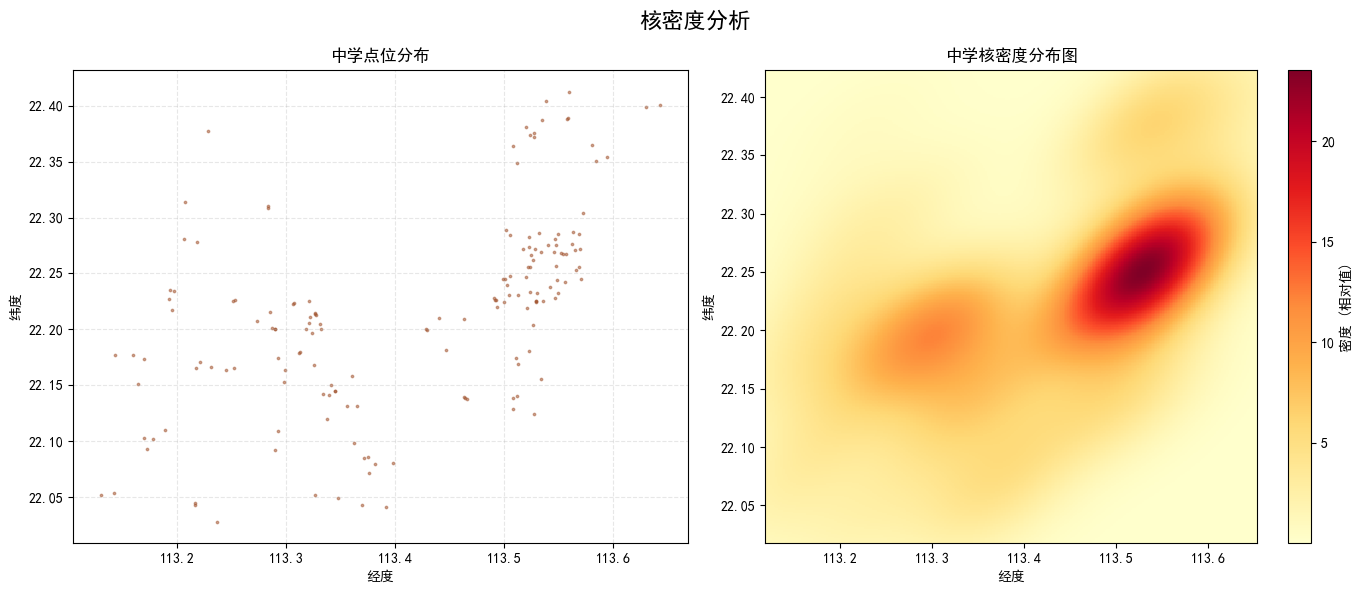

静态密度图已保存: output/school_kde.png


In [5]:
import matplotlib.pyplot as plt

# --------------------------
# 字体设置：解决 matplotlib 中文显示问题
# --------------------------
# Windows 常用 SimHei，Mac 常用 Arial Unicode MS，此处提供兼容写法
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# --------------------------
# 绘制图表
# --------------------------
# 创建 1行2列 的画板，并设置大小
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 添加全局大标题
fig.suptitle('核密度分析', fontsize=16)

# --- 子图 1: 餐厅点位分布 (左图) ---
# s=3 控制点的大小，color 设置点颜色，alpha 设置透明度
ax1.scatter(lons, lats, s=3, color='sienna', alpha=0.5) 
ax1.set_title('中学点位分布')
ax1.set_xlabel('经度')
ax1.set_ylabel('纬度')
ax1.grid(True, linestyle='--', alpha=0.3) # 添加浅色网格线

# --- 子图 2: 餐厅核密度分布图 (右图) ---
# 使用 pcolormesh 绘制网格密度，cmap='YlOrRd' 为黄-红渐变色带，非常贴合原图
im = ax2.pcolormesh(lon_mesh, lat_mesh, density, cmap='YlOrRd', shading='auto')
ax2.set_title('中学核密度分布图')
ax2.set_xlabel('经度')
ax2.set_ylabel('纬度')

# 为右图添加 Colorbar (颜色条)
cbar = fig.colorbar(im, ax=ax2)
cbar.set_label('密度 (相对值)')

# --------------------------
# 保存与显示
# --------------------------
# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout()
# 调整顶部边距，防止大标题与子图标题重叠
plt.subplots_adjust(top=0.88)

# 按照图片顶部的代码保存并显示图片
# 提示：确保当前工作目录下有一个名为 'output' 的文件夹，否则保存时会报错
import os
if not os.path.exists('output'):
    os.makedirs('output')

plt.savefig('output/school_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('静态密度图已保存: output/school_kde.png')

In [2]:
import folium
from folium.plugins import HeatMap
import numpy as np

print('正在生成 Folium 交互式热力图...')

# 1. 计算地图的中心点坐标，以便地图初始化时视野正好对准研究区域
center_lat = np.mean(lats)
center_lon = np.mean(lons)

# 2. 创建底图
# tiles='CartoDB positron' 会提供一个浅色的底图，能让红黄色的热力图更加显眼
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=12, 
    tiles='CartoDB positron'
)

# 3. 整理热力图数据
# Folium 的 HeatMap 需要的数据格式是包含 [纬度, 经度] 的列表
heat_data = [[lat, lon] for lat, lon in zip(lats, lons)]

# 4. 绘制热力图并添加到地图中
# 您可以根据实际的视觉效果微调 radius(半径) 和 blur(模糊度)
HeatMap(
    heat_data,
    radius=15,    
    blur=10,      
    max_zoom=13,  
    name='餐厅分布热力'
).add_to(m)

# 5. 添加图层控制器（可选，方便在右上角开启/关闭热力图层）
folium.LayerControl().add_to(m)

# 6. 保存为 HTML 文件
m.save('output/restaurant_heatmap.html')
print('交互热力图已保存: output/restaurant_heatmap.html')

# 提示：在 Jupyter Notebook 中，只需在下一行直接输入变量名 m 并运行，即可在页面内直接预览交互地图
m

正在生成 Folium 交互式热力图...
交互热力图已保存: output/restaurant_heatmap.html
